# DNN and XGBoost

In [26]:
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import torchvision

import numpy as np
import os
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import torch.nn.functional as F

import matplotlib.pyplot as plt
from IPython.display import clear_output

import xgboost as xgb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Unzip the data generated from the encoder

In [2]:
!unzip ./drive-download-20250612T040355Z-1-001.zip

Archive:  ./drive-download-20250612T040355Z-1-001.zip
  inflating: val_labels.pt           
  inflating: tr_labels.pt            
  inflating: val_logvar.pt           
  inflating: val_mu.pt               
  inflating: tr_logvar.pt            
  inflating: tr_mu.pt                


# Deep Neural Network

In [3]:
# Load train set
tr_logvar_list = torch.load("tr_logvar.pt")
tr_mu_list     = torch.load("tr_mu.pt")
tr_labels_list = torch.load("tr_labels.pt")

# Stack and convert to Tensor
tr_logvar = torch.stack(tr_logvar_list)
tr_mu     = torch.stack(tr_mu_list)

# Build integer labels
unique_labels  = sorted(set(tr_labels_list))
label_to_idx   = {lbl: idx for idx, lbl in enumerate(unique_labels)}
tr_labels_idx  = [label_to_idx[l] for l in tr_labels_list]
tr_labels      = torch.tensor(tr_labels_idx, dtype=torch.long)

# Move to device
tr_logvar = tr_logvar.to(device)
tr_mu     = tr_mu.to(device)
tr_labels = tr_labels.to(device)


In [4]:
# Simple DNN classifier
class DNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [5]:
# Number of samples per latent distribution
k = 5

In [6]:
# Augment train set
chunk_size = 1000

# Flatten latent dims
mu_flat   = tr_mu.view(tr_mu.size(0), -1)
std_flat  = (0.5 * tr_logvar).exp().view(tr_mu.size(0), -1)
N, D       = mu_flat.size()

z_chunks = []
y_chunks = []

for start in range(0, N, chunk_size):
    end    = min(start + chunk_size, N)
    mu_c   = mu_flat[start:end].cpu()
    std_c  = std_flat[start:end].cpu()
    lab_c  = tr_labels[start:end].cpu()

    # sample k times per latent distrivution
    eps_c = torch.randn(end - start, k, D)
    z_c   = mu_c.unsqueeze(1) + eps_c * std_c.unsqueeze(1)
    z_c   = z_c.view(-1, D)
    y_c   = lab_c.unsqueeze(1).repeat(1, k).view(-1)

    # back to GPU
    z_chunks.append(z_c.to(device))
    y_chunks.append(y_c.to(device))

z_train = torch.cat(z_chunks, dim=0)
y_train = torch.cat(y_chunks, dim=0)

print(f"Train z_train: {z_train.shape}, y_train: {y_train.shape}")


Train → z_train: torch.Size([240975, 128]), y_train: torch.Size([240975])


In [8]:
# Load validation set
val_logvar_list = torch.load("val_logvar.pt")
val_mu_list     = torch.load("val_mu.pt")
val_labels_list = torch.load("val_labels.pt")

val_logvar = torch.stack(val_logvar_list).to(device)
val_mu     = torch.stack(val_mu_list).to(device)

unique_labels_val  = sorted(set(val_labels_list))
label_to_idx_val   = {lbl: idx for idx, lbl in enumerate(unique_labels_val)}
val_labels_idx     = [label_to_idx_val[l] for l in val_labels_list]
val_labels         = torch.tensor(val_labels_idx, dtype=torch.long).to(device)


In [9]:
# Augment validation set
chunk_size = 1000

# Flatten latent dims
mu_flat_val  = val_mu.view(val_mu.size(0), -1)
std_flat_val = (0.5 * val_logvar).exp().view(val_mu.size(0), -1)
Nv, Dv       = mu_flat_val.size()

z_chunks = []
y_chunks = []

for start in range(0, Nv, chunk_size):
    end    = min(start + chunk_size, Nv)
    mu_c   = mu_flat_val[start:end].cpu()
    std_c  = std_flat_val[start:end].cpu()
    lab_c  = val_labels[start:end].cpu()

    # sample k times per latent distrivution
    eps_c = torch.randn(end - start, k, Dv)
    z_c   = mu_c.unsqueeze(1) + eps_c * std_c.unsqueeze(1)
    z_c   = z_c.view(-1, Dv)
    y_c   = lab_c.unsqueeze(1).repeat(1, k).view(-1)

    # back to GPU
    z_chunks.append(z_c.to(device))
    y_chunks.append(y_c.to(device))

z_val = torch.cat(z_chunks, dim=0)
y_val = torch.cat(y_chunks, dim=0)

print(f"Val z_val:   {z_val.shape}, y_val:   {y_val.shape}")


Val   → z_val:   torch.Size([80290, 128]), y_val:   torch.Size([80290])


In [10]:
# make the train test split out of the training dataset
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    z_train.cpu().numpy(),
    y_train.cpu().numpy(),
    test_size=0.2,
    random_state=42,
    stratify=y_train.cpu().numpy()
)

x_train = torch.tensor(X_train_np, dtype=torch.float32, device=device)
y_train = torch.tensor(y_train_np, dtype=torch.long,    device=device)
x_test  = torch.tensor(X_test_np,  dtype=torch.float32, device=device)
y_test  = torch.tensor(y_test_np,  dtype=torch.long,    device=device)

print("Augmented train:", x_train.shape, y_train.shape)
print("Augmented test: ",  x_test.shape,  y_test.shape)

Augmented train: torch.Size([192780, 128]) torch.Size([192780])
Augmented test:  torch.Size([48195, 128]) torch.Size([48195])


In [30]:
num_epochs = 5
test_losses = []
validation_losses = []

 Train Loss: 3.2887 | Val Loss: 3.2903


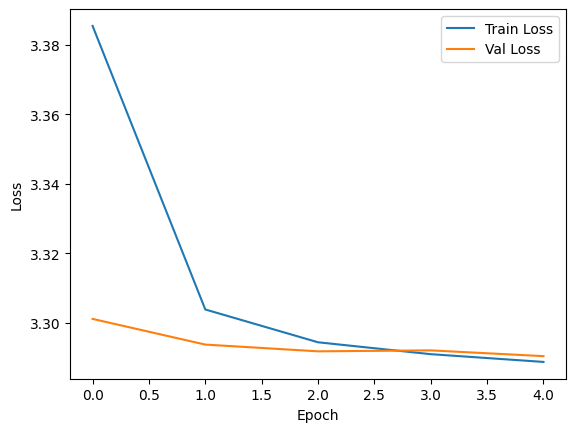

In [31]:
input_dim   = x_train.size(1)
hidden_dim  = 128
num_classes = 53

import torch
from torch.utils.data import TensorDataset, DataLoader

batch_size = 64
train_ds = TensorDataset(x_train, y_train)
val_ds   = TensorDataset(x_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, pin_memory=False)

# make model
classifier = DNNClassifier(input_dim=input_dim,
                           hidden_dim=hidden_dim,
                           num_classes=num_classes).to(device)
optimizer = torch.optim.Adam(
    classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4    # L2 penalty on all weights
)

criterion = nn.CrossEntropyLoss()

train_losses, val_losses = [], []

for epoch in range(1, num_epochs+1):
    print(f"Epoch {epoch}/{num_epochs}")
    # Training Pass
    classifier.train()
    running_train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        out = classifier(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Validation Pass
    classifier.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = classifier(xb)
            running_val_loss += criterion(out, yb).item() * xb.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # Plot
    clear_output(wait=True)
    print(f" Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses,   label='Val Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

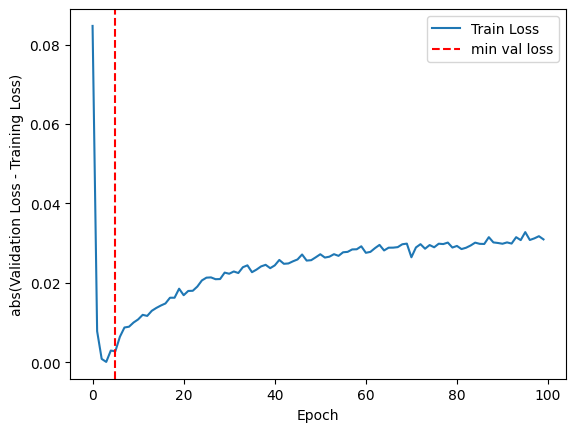

In [23]:
tx = [(abs(x1 - x2), i) for i, (x1, x2) in enumerate(zip(train_losses, val_losses))]

plt.plot([x[0] for x in tx], label='Train Loss')
plt.axvline(x=5, color='r', linestyle='--', label="min val loss")
plt.xlabel("Epoch")
plt.ylabel("abs(Validation Loss - Training Loss)")
plt.legend()
plt.show()

In [18]:
val_losses.index(min(val_losses))

5

In [33]:
# run the model in eval mode
classifier.eval()
with torch.no_grad():
    outputs = classifier(x_test)
    # pick the class with highest logit
    _, preds = torch.max(outputs, dim=1)

y_true = y_test.cpu().numpy()
y_pred = preds.cpu().numpy()

# Compute accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.2487


# XGBoost
Boosted Forrest

In [27]:
# make classifier object
clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric="mlogloss"
)

# Fit on the training set
clf.fit(X_train_np, y_train_np)

# Predict on the test set
y_pred = clf.predict(X_test_np)

# Compute accuracy
accuracy = accuracy_score(y_test_np, y_pred)
print(f"Test accuracy: {accuracy:.4f}")

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:39:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Test accuracy: 0.2486


In [29]:
y_pred = clf.predict(X_train_np)

accuracy = accuracy_score(y_train_np, y_pred)
print(f"Train accuracy: {accuracy:.4f}")

Train accuracy: 0.2740
